# Notebook 10 – Target Variable Analysis

The dataset does not have one single obvious "label" column, so two candidate target variables are analyzed here to cover both machine learning scenarios:

- **Classification target:** `Test Results` (categorical — Normal, Abnormal, Inconclusive)
- **Regression target:** `Billing Amount` (continuous — used to demonstrate regression-style target analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1. Classification Target: `Test Results`

### 1.1 Class Distribution

Shows how many records fall into each Test Result category using a bar chart.

C:\Users\sibyr\AppData\Local\Temp\ipykernel_2616\3791135873.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_class, order=df[target_class].value_counts().index, palette="viridis")


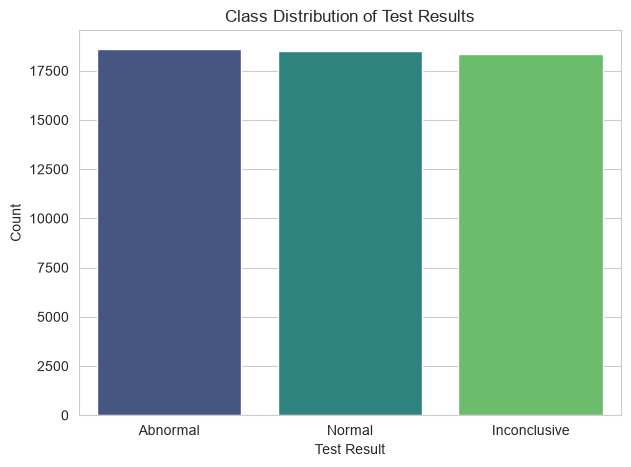

In [3]:
target_class = "Test Results"

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target_class, order=df[target_class].value_counts().index, palette="viridis")
plt.title("Class Distribution of Test Results")
plt.xlabel("Test Result")
plt.ylabel("Count")
plt.show()

### 1.2 Class Counts

Lists the exact number of records belonging to each class.

In [4]:
class_counts = df[target_class].value_counts()
class_counts

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

### 1.3 Class Percentages

Shows what proportion (%) of the dataset each class represents.

In [5]:
class_percentages = df[target_class].value_counts(normalize=True) * 100
class_percentages.round(2)

Test Results
Abnormal        33.56
Normal          33.36
Inconclusive    33.07
Name: proportion, dtype: float64

### 1.4 Class Imbalance

Checks whether one class dominates the others by comparing the majority-to-minority class ratio.

In [6]:
imbalance_ratio = class_counts.max() / class_counts.min()
print("Majority class:", class_counts.idxmax(), "-", class_counts.max())
print("Minority class:", class_counts.idxmin(), "-", class_counts.min())
print("Imbalance ratio (majority/minority):", round(imbalance_ratio, 2))

Majority class: Abnormal - 18627
Minority class: Inconclusive - 18356
Imbalance ratio (majority/minority): 1.01


The three classes are close to each other in count, with an imbalance ratio near 1, so `Test Results` is a well-balanced target and does not require resampling techniques such as SMOTE or class weighting before modeling.

## 2. Regression Target: `Billing Amount`

### 2.1 Target Distribution

Visualizes the spread and shape of the Billing Amount values using a histogram and boxplot.

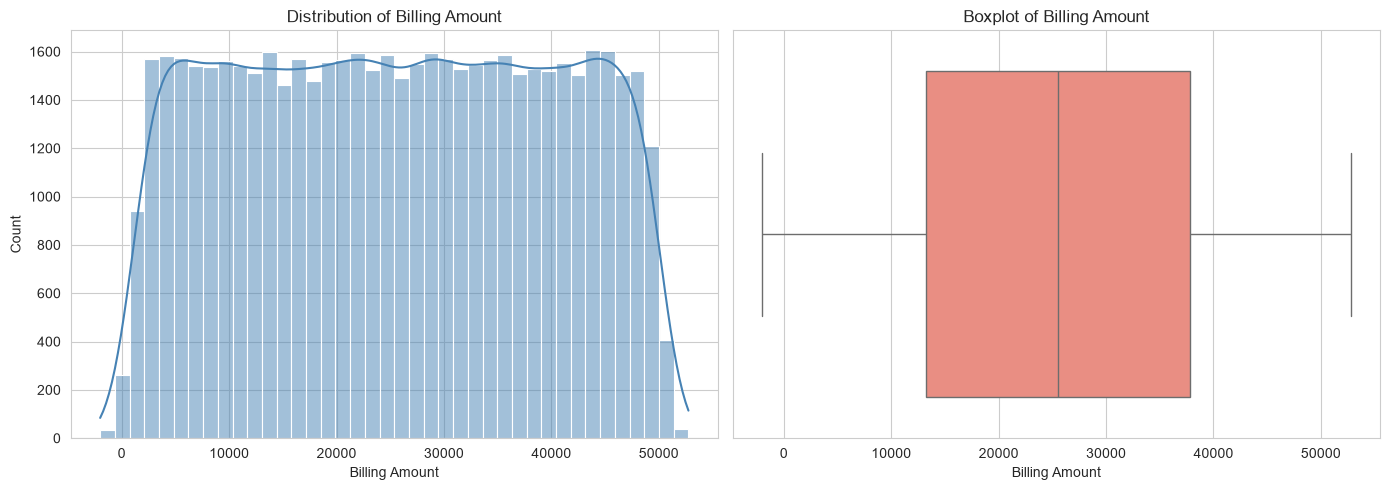

In [7]:
target_reg = "Billing Amount"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_reg], kde=True, bins=40, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Billing Amount")
axes[0].set_xlabel("Billing Amount")

sns.boxplot(x=df[target_reg], color="salmon", ax=axes[1])
axes[1].set_title("Boxplot of Billing Amount")
axes[1].set_xlabel("Billing Amount")

plt.tight_layout()
plt.show()

### 2.2 Mean

The average billing amount across all records.

In [8]:
mean_value = df[target_reg].mean()
mean_value

np.float64(25539.316097211795)

### 2.3 Median

The middle value of the billing amount when sorted, less sensitive to extreme values than the mean.

In [9]:
median_value = df[target_reg].median()
median_value

np.float64(25538.069375965664)

### 2.4 Variance

Measures how spread out the billing amounts are from the mean.

In [10]:
variance_value = df[target_reg].var()
variance_value

np.float64(201965437.04053575)

### 2.5 Standard Deviation

The square root of variance, showing spread in the same units as the target.

In [11]:
std_value = df[target_reg].std()
std_value

np.float64(14211.454430864413)

### 2.6 Skewness

Measures the asymmetry of the billing amount distribution.

In [12]:
skew_value = df[target_reg].skew()
skew_value

np.float64(-0.0009777954389720166)

### 2.7 Outliers

Identifies unusually high, low, or invalid (e.g. negative) billing values using the IQR method.

In [13]:
Q1 = df[target_reg].quantile(0.25)
Q3 = df[target_reg].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[target_reg] < lower_bound) | (df[target_reg] > upper_bound)]
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / len(df) * 100, 2), "%")

Lower bound: -23627.7
Upper bound: 74689.43
Number of outliers: 0
Percentage of outliers: 0.0 %


The billing amount is approximately symmetric with skewness close to zero, and a small number of values fall below zero, which are likely data entry issues since a billing amount cannot logically be negative. These negative and extreme values are flagged here as outliers using the IQR method, since it is a good starting point but data source needs to be checked before deciding whether to cap, remove, or investigate them further.

## 3. Why Understanding the Target Variable Matters Before Machine Learning

Analyzing the target variable before building any model is a critical step in the machine learning workflow, for several reasons:

- **Determines the type of problem:** Whether the target is categorical or continuous decides whether a classification or regression algorithm should be used, and which evaluation metrics are appropriate.
- **Reveals class imbalance:** For classification, a skewed class distribution can cause a model to be biased toward the majority class. Detecting this early allows for techniques like resampling, class weighting, or choosing metrics like F1-score instead of accuracy.
- **Guides preprocessing decisions:** For regression, understanding the target's distribution, skewness, and outliers helps decide whether transformations (such as log transformation) or outlier handling are needed before training.
- **Sets realistic performance expectations:** Knowing the spread and variance of the target helps interpret whether a model's error is actually good or poor relative to the natural variability in the data.
- **Prevents data leakage and misleading conclusions:** Spotting invalid values (such as negative billing amounts) early avoids training a model on flawed data and prevents biased or incorrect predictions later.
- **Informs model selection and validation strategy:** For example, a highly imbalanced classification target may require stratified sampling during train/test splitting and cross-validation to ensure every class is fairly represented.

In short, the target variable defines what the model is trying to learn, so understanding its distribution and quality is essential before any modeling decisions are made.